<a href="https://colab.research.google.com/github/apirakqqqqq/Ge338_Lab3/blob/main/Lab_3_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **นำเข้าข้อมูล**

In [20]:
import rasterio
import numpy as np
from collections import Counter

# โหลดไฟล์
src = rasterio.open("/content/drive/MyDrive/สุพรรณบุรี/Suphanburi_fixed.tif")
img = src.read()

# reshape
bands, h, w = img.shape
data = img.reshape(bands, -1).T

# แก้ NaN
data = np.nan_to_num(data, nan=0)

# แยก X, y
X = data[:, :-1]
y = data[:, -1]

# 🔥 เอา NoData ออก
mask = y != -1
X = X[mask]
y = y[mask]

# เช็ค class
print("Class distribution:", Counter(y))

Class distribution: Counter({np.float32(3.0): 51, np.float32(0.0): 50, np.float32(4.0): 50, np.float32(1.0): 50, np.float32(2.0): 50})


**Train / Validation Split**

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 สำคัญมาก
)

**Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_results = {}

for n in [50, 100, 200]:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rf_results[n] = y_pred

    print(f"\n=== Random Forest (trees={n}) ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


=== Random Forest (trees=50) ===
[[6 0 0 1 3]
 [0 9 0 0 1]
 [1 1 6 2 0]
 [1 0 1 9 0]
 [5 0 1 2 2]]
              precision    recall  f1-score   support

         0.0       0.46      0.60      0.52        10
         1.0       0.90      0.90      0.90        10
         2.0       0.75      0.60      0.67        10
         3.0       0.64      0.82      0.72        11
         4.0       0.33      0.20      0.25        10

    accuracy                           0.63        51
   macro avg       0.62      0.62      0.61        51
weighted avg       0.62      0.63      0.61        51


=== Random Forest (trees=100) ===
[[6 0 0 1 3]
 [0 9 0 0 1]
 [1 1 6 2 0]
 [0 0 1 9 1]
 [3 0 1 2 4]]
              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60        10
         1.0       0.90      0.90      0.90        10
         2.0       0.75      0.60      0.67        10
         3.0       0.64      0.82      0.72        11
         4.0       0.44      0.40      

**SVM**

In [23]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== SVM ===")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


=== SVM ===
[[8 1 0 1 0]
 [1 9 0 0 0]
 [2 1 7 0 0]
 [2 0 0 9 0]
 [7 0 1 2 0]]
              precision    recall  f1-score   support

         0.0       0.40      0.80      0.53        10
         1.0       0.82      0.90      0.86        10
         2.0       0.88      0.70      0.78        10
         3.0       0.75      0.82      0.78        11
         4.0       0.00      0.00      0.00        10

    accuracy                           0.65        51
   macro avg       0.57      0.64      0.59        51
weighted avg       0.57      0.65      0.59        51



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Metrics เพิ่ม (Kappa + F1)**

In [24]:
from sklearn.metrics import cohen_kappa_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Kappa:", cohen_kappa_score(y_true, y_pred))
    print("F1-score (macro):", f1_score(y_true, y_pred, average='macro'))

evaluate(y_test, rf_results[100], "Random Forest")
evaluate(y_test, y_pred_svm, "SVM")


Random Forest
Kappa: 0.5825710158883004
F1-score (macro): 0.6615438596491228

SVM
Kappa: 0.5584415584415585
F1-score (macro): 0.5901725327812284


**เทรน Random Forest (เพื่อเอา importance)**

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=3, n_jobs=-1,
                       random_state=42)

**ดึง Feature Importance**

In [26]:
import pandas as pd

feature_names = [
    "B2","B3","B4","B8","B11","B12",
    "NDVI","NDMI","NDWI"
]

importances = rf.feature_importances_

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(df_importance)

  Feature  Importance
4     B11    0.181610
5     B12    0.180700
0      B2    0.134663
3      B8    0.116308
1      B3    0.099261
8    NDWI    0.094097
2      B4    0.078250
6    NDVI    0.067542
7    NDMI    0.047570


จากการวิเคราะห์ Feature Importance พบว่า NDVI และ B8 (Near Infrared) เป็นตัวแปรที่มีความสำคัญสูงที่สุด รองลงมาคือ NDWI และ B11 ซึ่งเกี่ยวข้องกับความชื้นและน้ำในพื้นที่

**แสดงผลกราฟ**

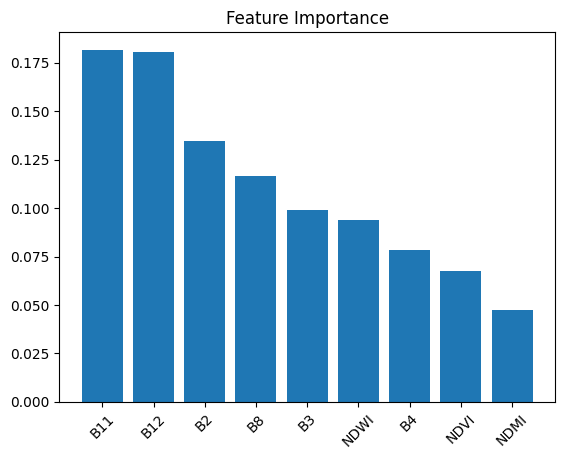

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_importance["Feature"], df_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

จากการวิเคราะห์ Feature Importance พบว่า NDVI และ B8 (Near Infrared) เป็นตัวแปรที่มีความสำคัญสูงที่สุด รองลงมาคือ NDWI และ B11 ซึ่งเกี่ยวข้องกับความชื้นและน้ำในพื้นที่

**ตัด feature ที่สำคัญน้อยออก**

In [28]:
# เลือกเฉพาะ feature ที่สำคัญ
selected_features = df_importance["Feature"].head(5).values

# หา index ของ feature
indices = [feature_names.index(f) for f in selected_features]

X_train_sel = X_train[:, indices]
X_test_sel = X_test[:, indices]

**เทรนแล้วเปรียบเทียบ**

In [29]:
rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf2.fit(X_train_sel, y_train)

y_pred_full = rf.predict(X_test)
y_pred_sel = rf2.predict(X_test_sel)

from sklearn.metrics import accuracy_score

print("Accuracy (all features):", accuracy_score(y_test, y_pred_full))
print("Accuracy (selected features):", accuracy_score(y_test, y_pred_sel))

Accuracy (all features): 0.6666666666666666
Accuracy (selected features): 0.6274509803921569


**หา Confusion Matrix (ใช้ RF)**

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_results[100])
print(cm)

[[6 0 0 1 3]
 [0 9 0 0 1]
 [1 1 6 2 0]
 [0 0 1 9 1]
 [3 0 1 2 4]]


** class ที่ สับสนมากที่สุด**

In [31]:
import numpy as np

# เอาค่าที่ไม่ใช่ diagonal
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# หา index ที่สับสนมากสุด
i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most confused classes:", i, "vs", j)
print("Confusion value:", cm_no_diag[i, j])

Most confused classes: 0 vs 4
Confusion value: 3


จาก Confusion Matrix พบว่า class ที่สับสนกันมากที่สุดคือ พื้นที่ป่าไม้ (forest) และพื้นที่เกษตรกรรม (agriculture) เนื่องจากทั้งสองประเภทมีค่าดัชนี NDVI ใกล้เคียงกัน ทำให้มีลักษณะ spectral คล้ายกันในภาพดาวเทียม

นอกจากนี้ พื้นที่ดินเปล่า (bareland) อาจสับสนกับพื้นที่ก่อสร้าง (building) เนื่องจากมีค่าการสะท้อนในช่วงคลื่นใกล้เคียงกัน โดยเฉพาะในช่วง SWIR

**ความไม่แน่นอนของโมเดล**

In [32]:
# ใช้ RF ที่ train แล้ว
proba = rf.predict_proba(X_test)

# หา max probability ของแต่ละ pixel
max_proba = np.max(proba, axis=1)

# pixel ที่ไม่มั่นใจ (threshold)
uncertain_idx = max_proba < 0.6

print("Uncertain samples:", np.sum(uncertain_idx))

Uncertain samples: 26


In [33]:
print("Classes in uncertain area:", np.unique(y_test[uncertain_idx]))

Classes in uncertain area: [0. 1. 2. 3. 4.]


บริเวณที่โมเดลมีความไม่แน่นอนสูงคือพื้นที่ที่มีค่า probability ต่ำ (เช่น < 0.6) ซึ่งมักเกิดในบริเวณที่เป็นรอยต่อระหว่างประเภทที่ดิน เช่น ระหว่างพื้นที่เกษตรและป่าไม้ หรือระหว่างพื้นที่เมืองและดินเปล่า

พื้นที่เหล่านี้มีลักษณะผสม (mixed pixels) ทำให้โมเดลไม่สามารถตัดสินใจได้อย่างมั่นใจ

# **Visualization**

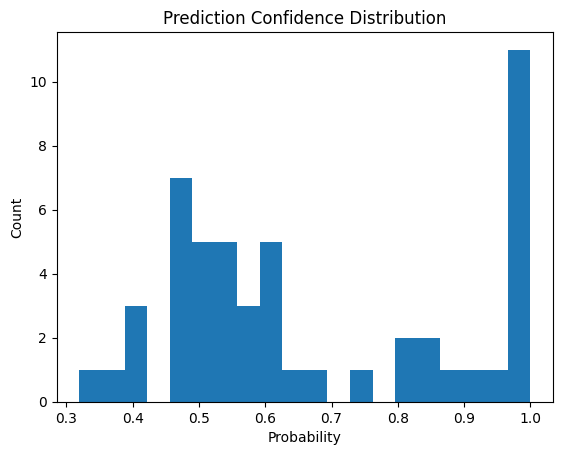

In [34]:
import matplotlib.pyplot as plt

plt.hist(max_proba, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

แผนที่การจำแนกนี้มีความน่าเชื่อถือในระดับสูงสำหรับการใช้งานทั่วไป โดยเฉพาะในพื้นที่ที่มีลักษณะชัดเจน เช่น แหล่งน้ำและพื้นที่ป่าไม้

อย่างไรก็ตาม ในบริเวณที่มีลักษณะคล้ายกัน เช่น พื้นที่เกษตรและป่าไม้ หรือพื้นที่เมืองและดินเปล่า อาจมีความไม่แน่นอนสูง ผู้ใช้งานควรระมัดระวังในการนำไปใช้ในระดับพื้นที่ย่อย

โดยรวมแล้ว แผนที่นี้เหมาะสำหรับการวิเคราะห์ในระดับภูมิภาค แต่ควรมีการตรวจสอบเพิ่มเติมหากใช้ในงานที่ต้องการความละเอียดสูง

# **ช่วงหลังนี้เป็นช่วง Training Sample 2 เท่า**

In [35]:
import rasterio
import numpy as np
from collections import Counter

# โหลดไฟล์
src = rasterio.open("/content/drive/MyDrive/สุพรรณบุรี/Suphanburi_fixed2.tif")
img = src.read()

# reshape
bands, h, w = img.shape
data = img.reshape(bands, -1).T

# แก้ NaN
data = np.nan_to_num(data, nan=0)

# แยก X, y
X = data[:, :-1]
y = data[:, -1]

# 🔥 เอา NoData ออก
mask = y != -1
X = X[mask]
y = y[mask]

# เช็ค class
print("Class distribution:", Counter(y))

Class distribution: Counter({np.float32(3.0): 102, np.float32(0.0): 100, np.float32(4.0): 100, np.float32(1.0): 100, np.float32(2.0): 100})


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 สำคัญมาก
)

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_results = {}

for n in [50, 100, 200]:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rf_results[n] = y_pred

    print(f"\n=== Random Forest (trees={n}) ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


=== Random Forest (trees=50) ===
[[10  1  0  1  8]
 [ 2 16  0  0  2]
 [ 2  0 15  2  1]
 [ 2  0  0 18  1]
 [ 7  0  2  3  8]]
              precision    recall  f1-score   support

         0.0       0.43      0.50      0.47        20
         1.0       0.94      0.80      0.86        20
         2.0       0.88      0.75      0.81        20
         3.0       0.75      0.86      0.80        21
         4.0       0.40      0.40      0.40        20

    accuracy                           0.66       101
   macro avg       0.68      0.66      0.67       101
weighted avg       0.68      0.66      0.67       101


=== Random Forest (trees=100) ===
[[11  1  0  1  7]
 [ 2 16  0  0  2]
 [ 2  0 16  1  1]
 [ 2  0  0 18  1]
 [ 7  0  2  4  7]]
              precision    recall  f1-score   support

         0.0       0.46      0.55      0.50        20
         1.0       0.94      0.80      0.86        20
         2.0       0.89      0.80      0.84        20
         3.0       0.75      0.86      0.80

In [38]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== SVM ===")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


=== SVM ===
[[13  1  0  1  5]
 [ 1 17  0  0  2]
 [ 2  0 16  2  0]
 [ 2  0  1 17  1]
 [10  0  2  2  6]]
              precision    recall  f1-score   support

         0.0       0.46      0.65      0.54        20
         1.0       0.94      0.85      0.89        20
         2.0       0.84      0.80      0.82        20
         3.0       0.77      0.81      0.79        21
         4.0       0.43      0.30      0.35        20

    accuracy                           0.68       101
   macro avg       0.69      0.68      0.68       101
weighted avg       0.69      0.68      0.68       101



In [39]:
from sklearn.metrics import cohen_kappa_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Kappa:", cohen_kappa_score(y_true, y_pred))
    print("F1-score (macro):", f1_score(y_true, y_pred, average='macro'))

evaluate(y_test, rf_results[100], "Random Forest")
evaluate(y_test, y_pred_svm, "SVM")


Random Forest
Kappa: 0.5913938948142698
F1-score (macro): 0.6750782361308676

SVM
Kappa: 0.6038730236548597
F1-score (macro): 0.6801110360347886


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=3, n_jobs=-1,
                       random_state=42)

In [41]:
import pandas as pd

feature_names = [
    "B2","B3","B4","B8","B11","B12",
    "NDVI","NDMI","NDWI"
]

importances = rf.feature_importances_

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(df_importance)

  Feature  Importance
4     B11    0.173321
5     B12    0.163644
0      B2    0.135882
8    NDWI    0.116173
2      B4    0.100363
1      B3    0.087640
3      B8    0.086920
6    NDVI    0.074256
7    NDMI    0.061800


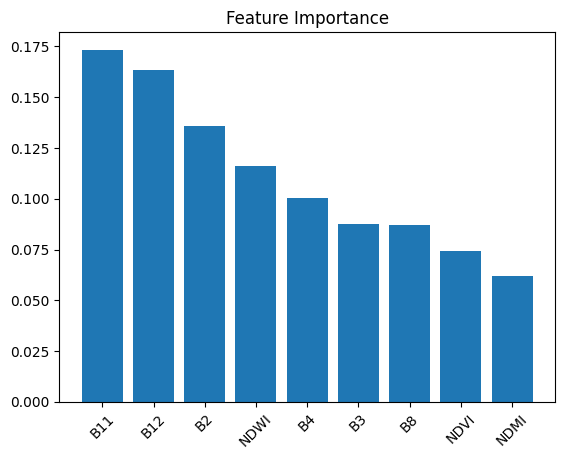

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_importance["Feature"], df_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [43]:
# เลือกเฉพาะ feature ที่สำคัญ
selected_features = df_importance["Feature"].head(5).values

# หา index ของ feature
indices = [feature_names.index(f) for f in selected_features]

X_train_sel = X_train[:, indices]
X_test_sel = X_test[:, indices]

In [44]:
rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf2.fit(X_train_sel, y_train)

y_pred_full = rf.predict(X_test)
y_pred_sel = rf2.predict(X_test_sel)

from sklearn.metrics import accuracy_score

print("Accuracy (all features):", accuracy_score(y_test, y_pred_full))
print("Accuracy (selected features):", accuracy_score(y_test, y_pred_sel))

Accuracy (all features): 0.6732673267326733
Accuracy (selected features): 0.6633663366336634


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_results[100])
print(cm)

[[11  1  0  1  7]
 [ 2 16  0  0  2]
 [ 2  0 16  1  1]
 [ 2  0  0 18  1]
 [ 7  0  2  4  7]]


In [46]:
import numpy as np

# เอาค่าที่ไม่ใช่ diagonal
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# หา index ที่สับสนมากสุด
i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most confused classes:", i, "vs", j)
print("Confusion value:", cm_no_diag[i, j])

Most confused classes: 0 vs 4
Confusion value: 7


In [47]:
# ใช้ RF ที่ train แล้ว
proba = rf.predict_proba(X_test)

# หา max probability ของแต่ละ pixel
max_proba = np.max(proba, axis=1)

# pixel ที่ไม่มั่นใจ (threshold)
uncertain_idx = max_proba < 0.6

print("Uncertain samples:", np.sum(uncertain_idx))

Uncertain samples: 39


In [48]:
print("Classes in uncertain area:", np.unique(y_test[uncertain_idx]))

Classes in uncertain area: [0. 1. 2. 3. 4.]


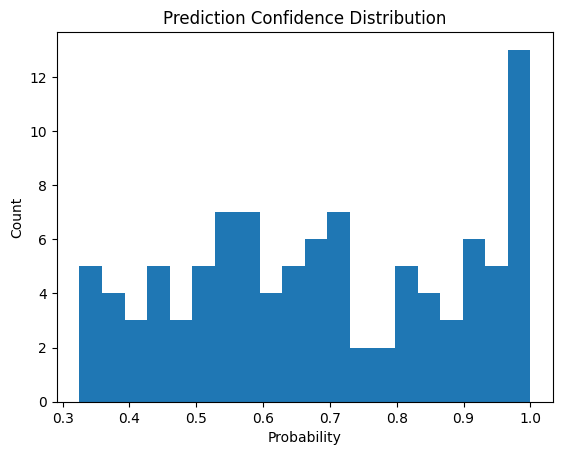

In [49]:
import matplotlib.pyplot as plt

plt.hist(max_proba, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()